In [ ]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset

In [2]:
import visualization.visualization as vis

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
from nemi import NEMI, SingleNemi

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import numpy as np

import colorsys
from einops import rearrange
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import itertools

In [5]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [ ]:
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

In [ ]:
single_image = dataset.X[0]

print(single_image.shape)

In [ ]:
import math

patch_size = 8
patches = dataset.get_patches(patch_size=patch_size)   # (N_patches, C_feat*p*p), coords excluded

print(patches.shape)
print(math.log(patches.shape[0]) + 15)

In [9]:
EMBEDDING_DIMENSIONS = 3

In [10]:
# # Run NEMI on the patches (GPU: cuML UMAP + clustering)
# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 150, "min_dist": 0.0},
#     "clustering_dict": {"method": "hdbscan", "min_cluster_size": 1000, "min_samples": 500},
# })

# # nemi = NEMI(params={
# #     "device": "gpu",
# #     "embedding_dict":  {"n_components": 2, "n_neighbors": 150, "min_dist": 0.0},
# #     "clustering_dict": {"method": "agglomerative", "n_clusters": 500, "linkage": "single", "n_neighbors": 30},
# # })


# # single member to start; bump n (with assess_overlap=True) for the ensemble
# nemi.run(patches, n=5, output="nemi_out.npz", assess_overlap=True)

# labels    = nemi.clusters      # (N,) cluster label per patch
# embedding = nemi.embedding     # (N, 3) UMAP embedding
# print("labels", labels.shape, "| embedding", embedding.shape)

In [11]:
d = np.load("nemi_out.npz")
print(d.files) 

member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
embedding       = d["embedding"]        # (N, d) consensus/base embedding
entropy         = d["entropy"]
unassigned      = d["unassigned_frac"]

print(embeddings.shape)
print(member_clusters.shape)
print(clusters.shape)
print(embedding.shape)
print(entropy.shape)
print(unassigned.shape)

['embeddings', 'member_clusters', 'clusters', 'embedding', 'entropy', 'unassigned_frac']
(5, 208000, 3)
(5, 208000)
(208000,)
(208000, 3)
(208000,)
(208000,)


In [13]:
# def distinct_cmap(n):
#     """Qualitative colormap with n visually distinct colors (tab20-style, any n)."""
#     colors = []
#     for i in range(n):
#         h = (i * 0.61803398875) % 1.0        # golden-ratio hue spacing
#         s = 0.55 + 0.35 * (i % 2)            # two saturation tiers
#         v = 0.75 + 0.20 * ((i // 2) % 2)     # two value tiers
#         colors.append(colorsys.hsv_to_rgb(h, s, v))
#     return ListedColormap(colors)

# disc_cmap = distinct_cmap(len(clusters))

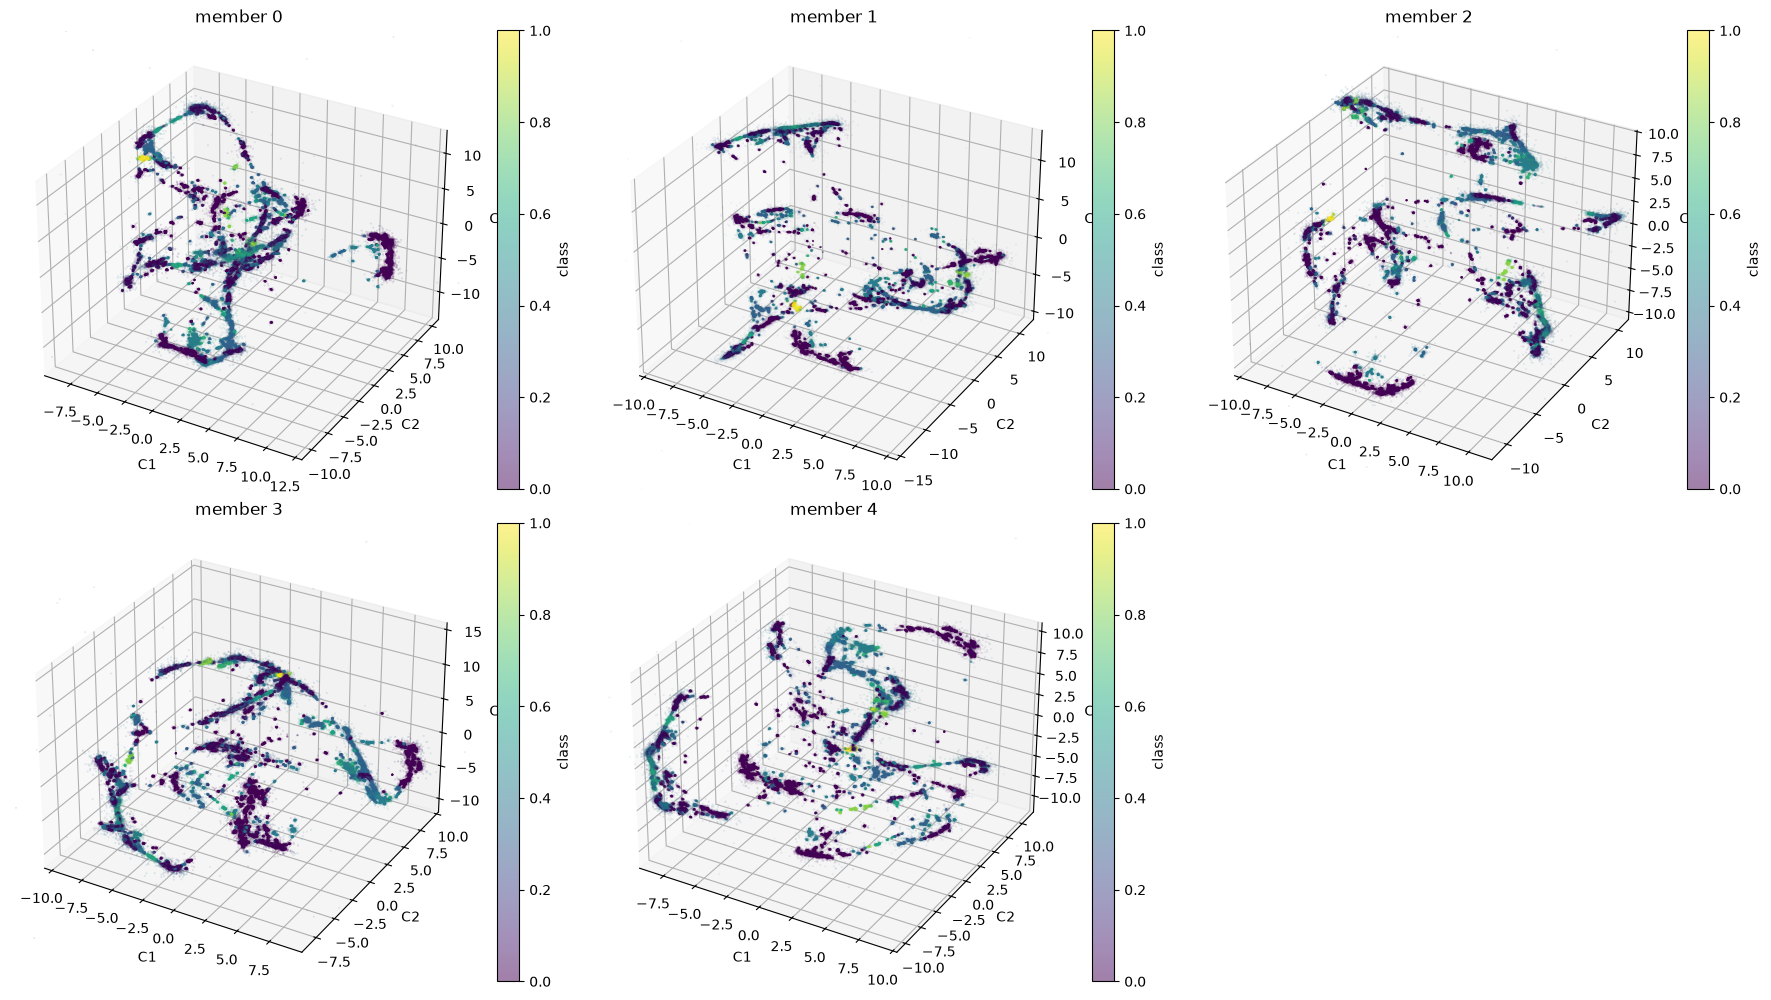

In [12]:
# vis.vis_dim_redux(embeddings[1], labels=entropy, dims=2, alpha=0.5, categorical=False, cmap="viridis")

vis.vis_dim_redux_list(d["embeddings"], labels=entropy, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

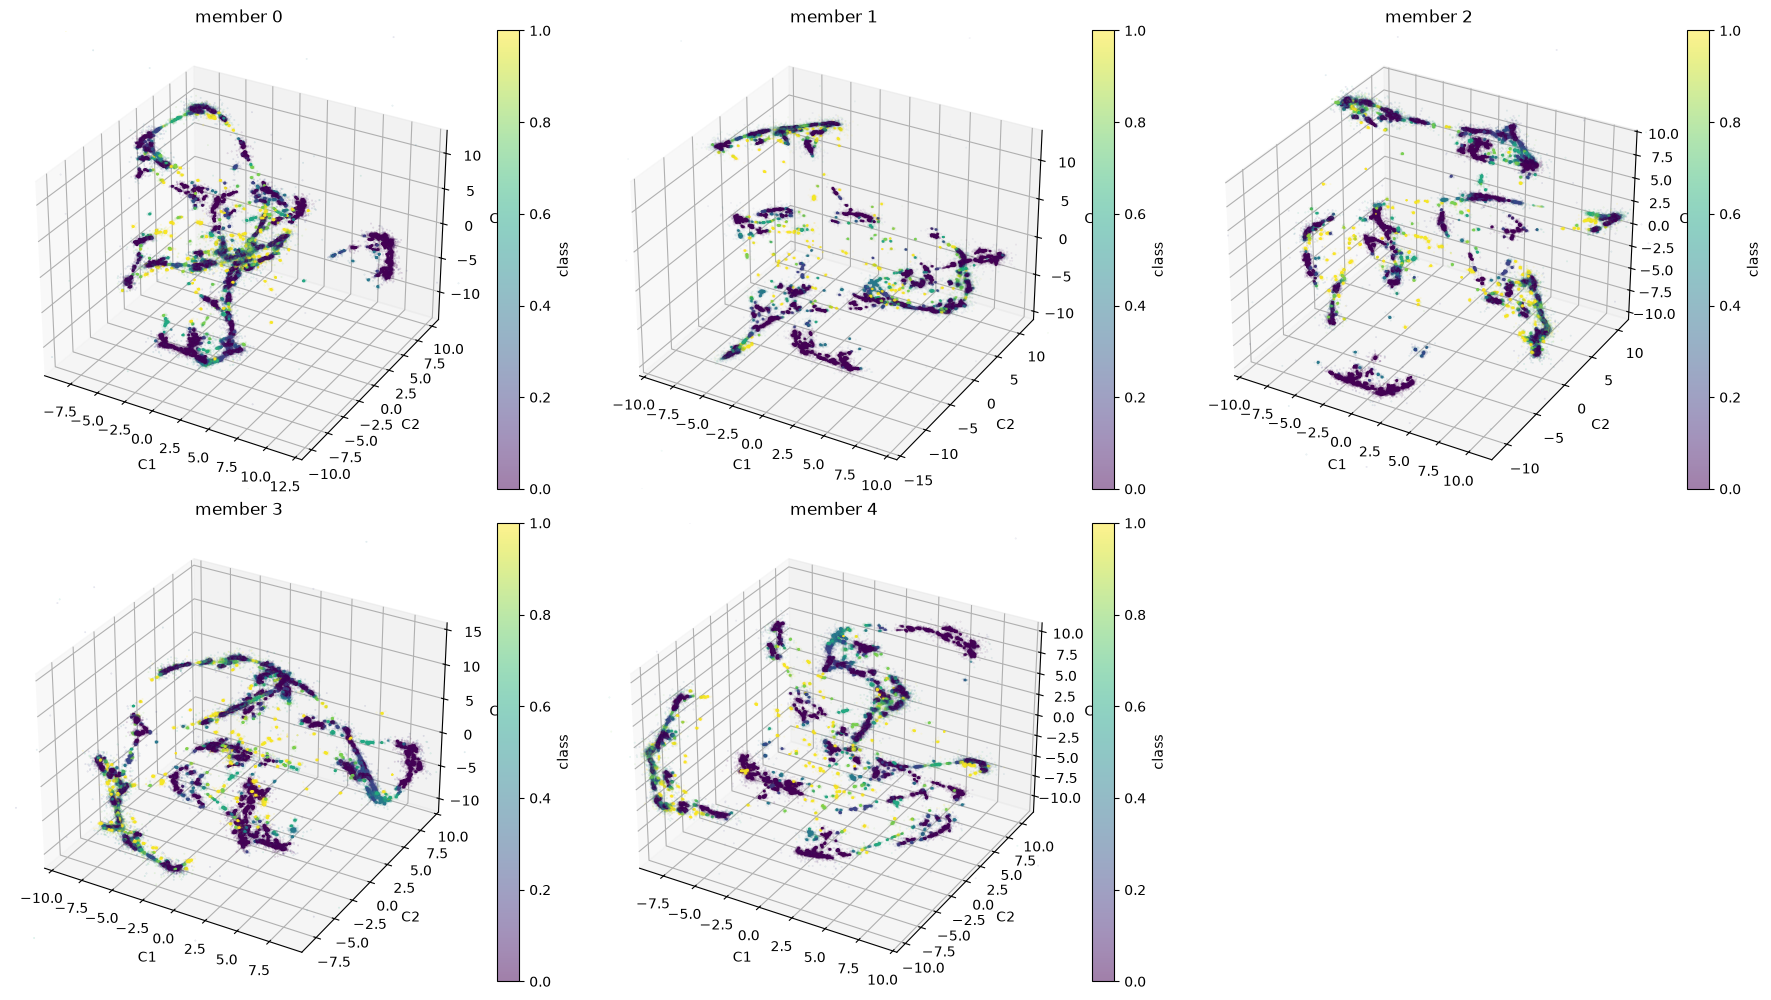

In [13]:
vis.vis_dim_redux_list(d["embeddings"], labels=unassigned, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

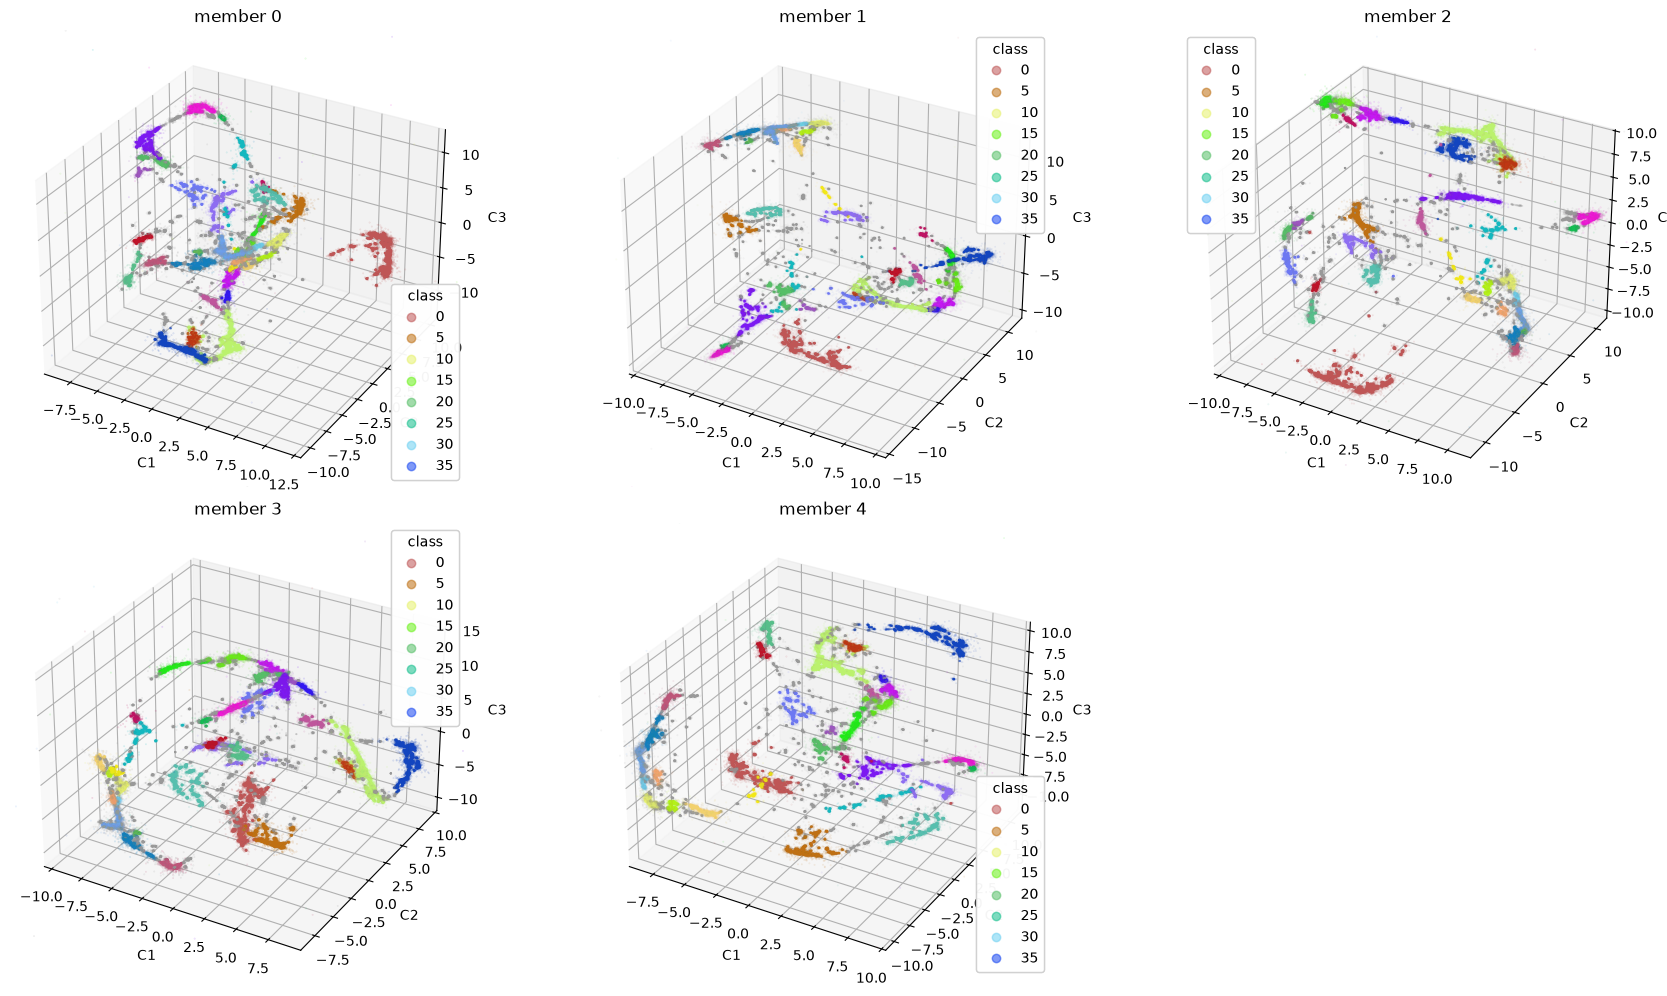

In [14]:
#labeled by consensus cluster
vis.vis_dim_redux_list(d["embeddings"], labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(d["embeddings"]))], alpha=0.5)

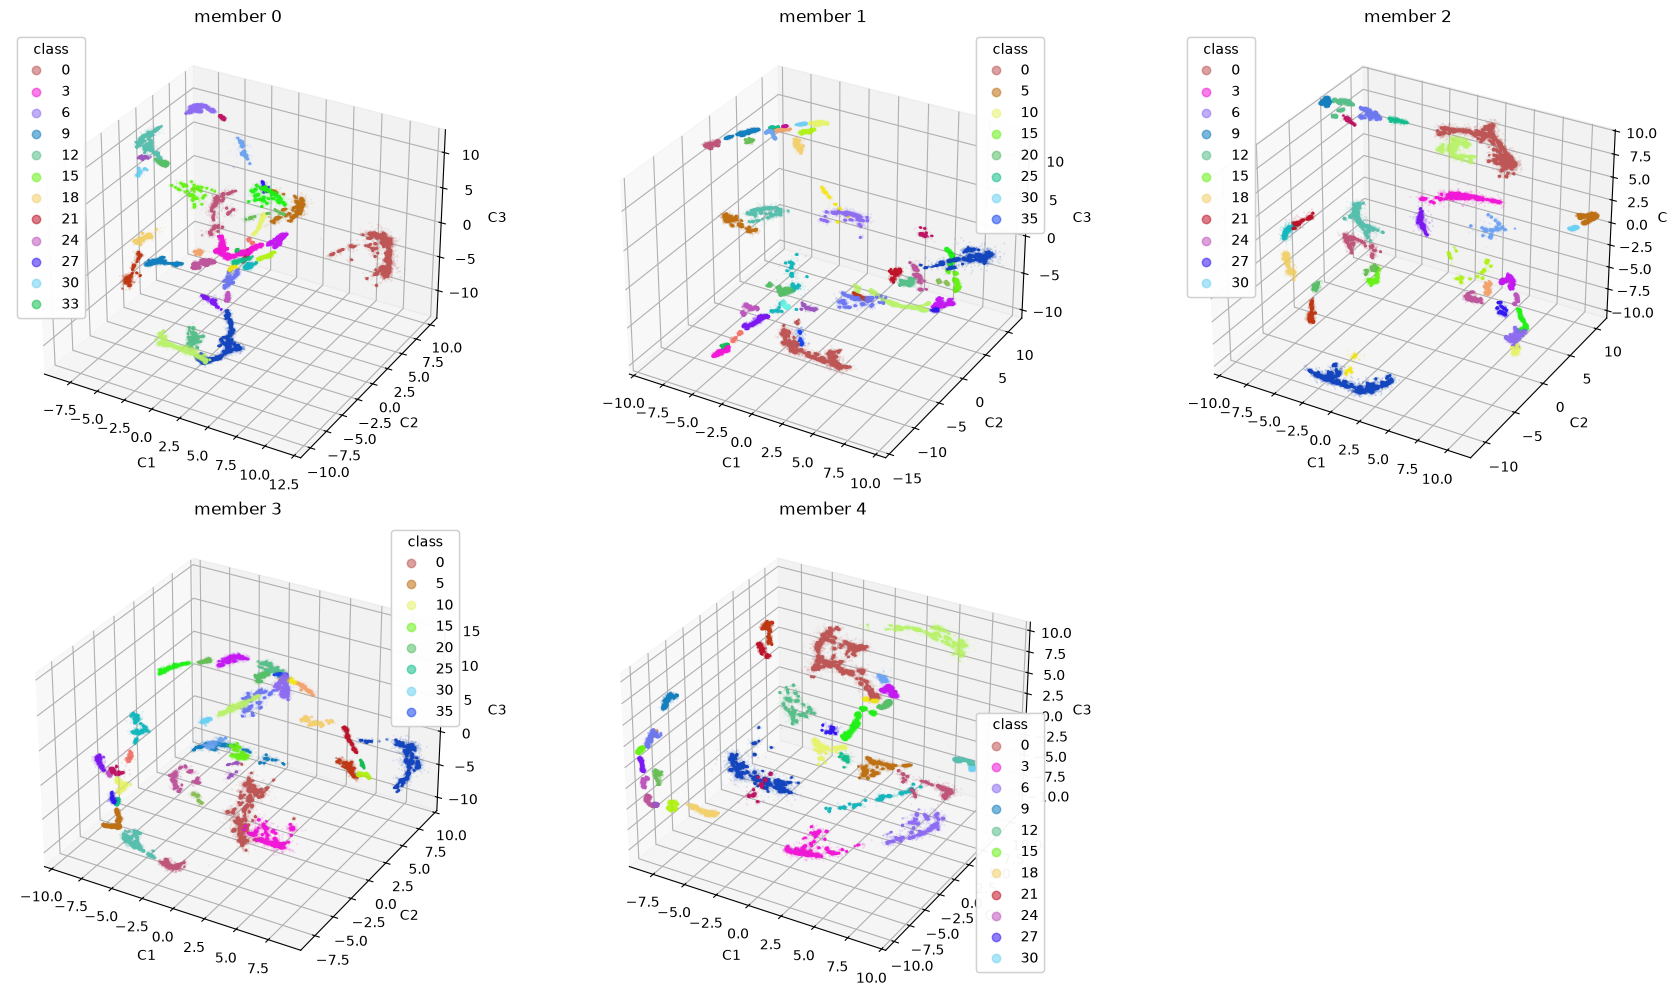

In [15]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))])

In [16]:
np.unique(clusters)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       36])

In [ ]:
vis.plot_global_cluster_maps(dataset, clusters, patch_size=8, alpha=0.5, point_size=8, extent=None,
                             coastlines=True, panel_size=8, drop_noise=False,
                             save_dir=None)

In [ ]:
vis.make_image_from_patches(dataset, clusters, patch_size=8, number_rows=10)